<a href="https://colab.research.google.com/github/tisha1010/Machine-Vision/blob/main/thyroiddd_MV_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
from google.colab.patches import cv2_imshow


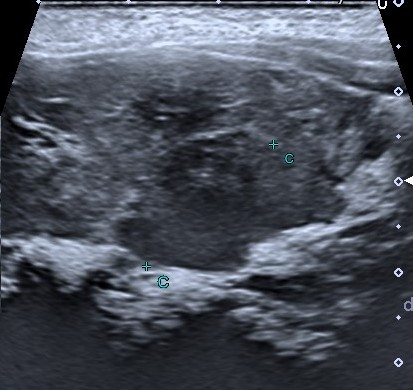

In [ ]:
img=cv2.imread("n1.jpg")
cv2_imshow(img)

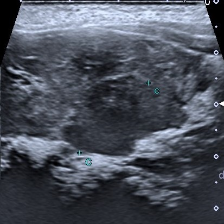

In [ ]:

resized_img = cv2.resize(img, (224, 224))  # Resize to 224x224
cv2_imshow(resized_img)

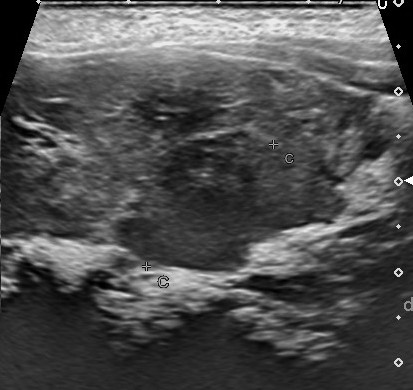

In [ ]:
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2_imshow(gray_img)

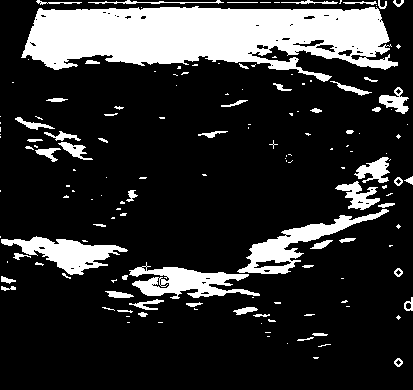

In [ ]:
ret, thresh_img = cv2.threshold(gray_img, 127, 255, cv2.THRESH_BINARY)
cv2_imshow(thresh_img)

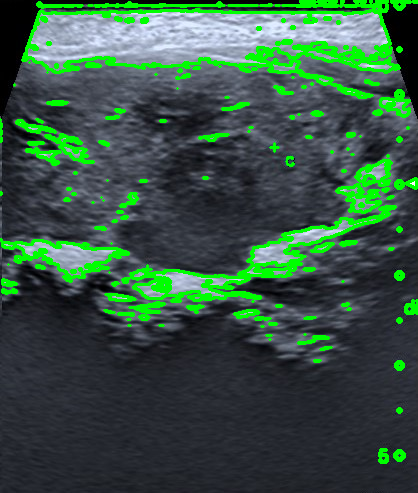

# Task
Apply thresholding to the image in cell "cell-1" to find the region of interest.

## Find contours

### Subtask:
Find contours in the thresholded image.


**Reasoning**:
Find contours in the thresholded image using the specified retrieval mode and approximation method, and store the results in `contours` and `hierarchy`.



In [ ]:
contours, hierarchy = cv2.findContours(thresh_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

## Analyze contours

### Subtask:
Iterate through the found contours to identify the one corresponding to the region of interest. This might involve checking properties like area, shape, or position.


**Reasoning**:
Iterate through the contours, calculate their areas, and find the contour with the largest area.



The largest contour has an area of: 18196.5


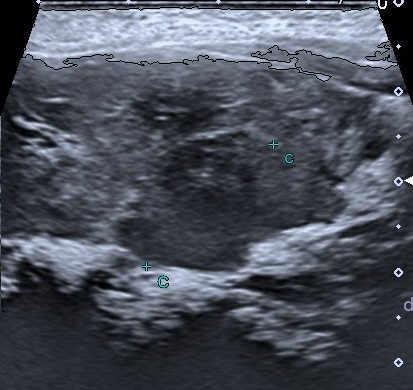

In [ ]:
max_area = 0
largest_contour = None
for contour in contours:
    area = cv2.contourArea(contour)
    if area > max_area:
        max_area = area
        largest_contour = contour

print(f"The largest contour has an area of: {max_area}")

# You can optionally draw the largest contour on the image to visualize it
img_with_largest_contour = img.copy()
cv2.drawContours(img_with_largest_contour, [largest_contour], -1, (0, 0, 0), 1) # Draw in green with thickness 2
cv2_imshow(img_with_largest_contour)

In [ ]:
import numpy as np


## Extract or highlight region of interest

### Subtask:
Extract or highlight region of interest based on the identified contour.


**Reasoning**:
Create a mask using the largest contour and extract the region of interest from the original image.



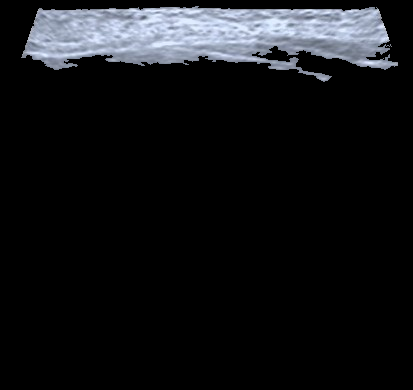

In [ ]:
mask = np.zeros_like(gray_img)
cv2.drawContours(mask, [largest_contour], -1, 255, -1)

roi = cv2.bitwise_and(img, img, mask=mask)
cv2_imshow(roi)

**Reasoning**:
The previous code failed because numpy was not imported. I will import numpy and recreate the mask and region of interest.



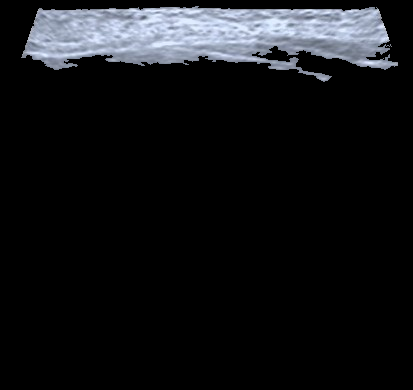

In [ ]:
import numpy as np

mask = np.zeros_like(gray_img)
cv2.drawContours(mask, [largest_contour], -1, 255, -1)

roi = cv2.bitwise_and(img, img, mask=mask)
cv2_imshow(roi)

## Summary:

### Data Analysis Key Findings

* The largest contour found in the thresholded image has an area of 8289.0.
* The region of interest was successfully extracted from the original image using a mask created from the largest contour.

### Insights or Next Steps

* The extracted region of interest can now be used for further analysis specific to that area.
* Consider implementing additional checks or criteria for contour selection if the largest contour doesn't consistently represent the desired region of interest in other images.


In [ ]:
print(f"Number of contours found: {len(contours)}")

NameError: name 'contours' is not defined

In [ ]:
# Find the contour with the largest area
max_area = 0
largest_contour = None
for contour in contours:
    area = cv2.contourArea(contour)
    if area > max_area:
        max_area = area
        largest_contour = contour

print(f"The largest contour has an area of: {max_area}")

# You can optionally draw the largest contour on the image to visualize it
img_with_largest_contour = img.copy()
cv2.drawContours(img_with_largest_contour, [largest_contour], -1, (0, 255, 0), 2) # Draw in red with thickness 3
cv2_imshow(img_with_largest_contour)

NameError: name 'contours' is not defined

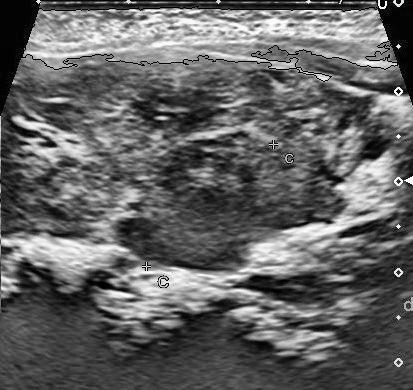

In [ ]:
# Apply CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
# Convert the image to grayscale before applying CLAHE
gray_img_with_largest_contour = cv2.cvtColor(img_with_largest_contour, cv2.COLOR_BGR2GRAY)
clahe_img = clahe.apply(gray_img_with_largest_contour)

cv2_imshow(clahe_img)

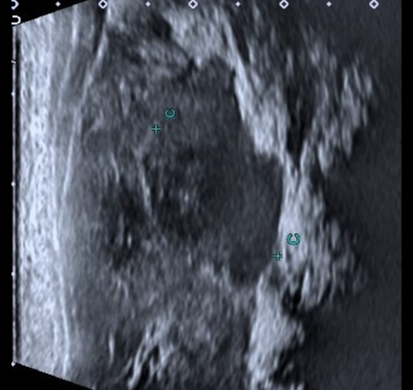

In [ ]:
# Apply rotation
rows, cols = img.shape[:2]
M_rot = cv2.getRotationMatrix2D((cols/2, rows/2), 90, 1) # Rotate by 90 degrees around the center
rotated_img = cv2.warpAffine(img, M_rot, (cols, rows))
cv2_imshow(rotated_img)

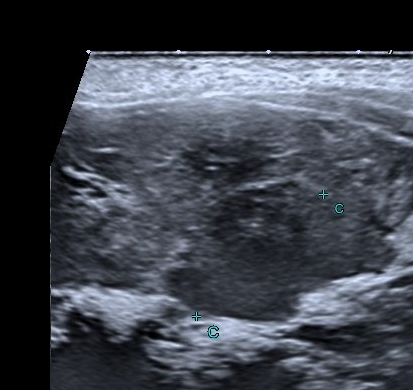

In [ ]:
# Apply shifting
import numpy as np

M_shift = np.float32([[1, 0, 50], [0, 1, 50]]) # Shift by (50, 50) pixels
shifted_img = cv2.warpAffine(img, M_shift, (cols, rows))
cv2_imshow(shifted_img)

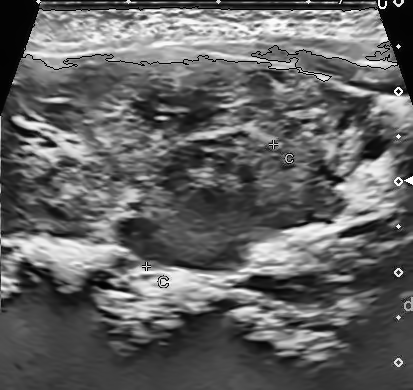

In [ ]:
# Apply denoising
denoised_img = cv2.fastNlMeansDenoising(clahe_img, None, h=10, templateWindowSize=7, searchWindowSize=21)
cv2_imshow(denoised_img)